In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

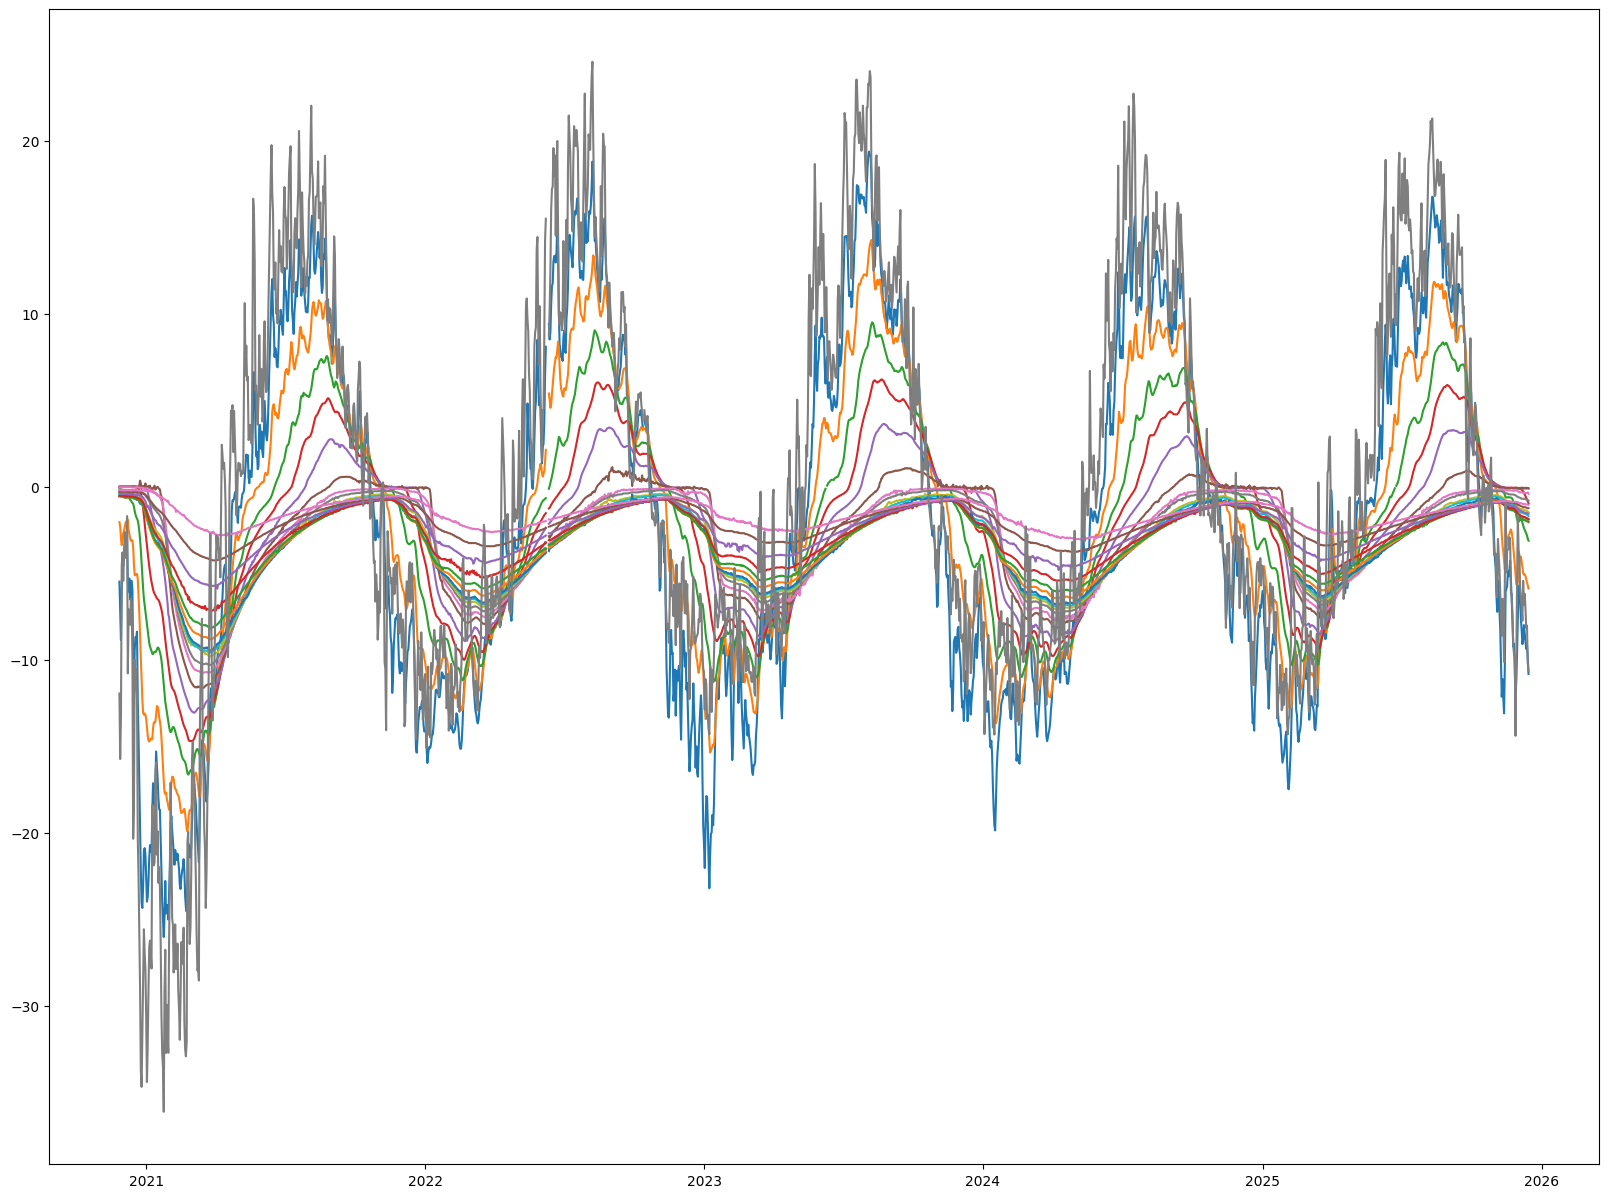

In [2]:
df = pd.read_csv('../data/raw/ZK 68, (48-1, 48-air), 27.11.20-15.12.25.csv', sep=';', decimal=',')
df['Дата'] = pd.to_datetime(df['Дата'])
df = df.drop(columns=['Время'])

# поиск и добавление пропущенных дней
df.index = df['Дата']
df = df.drop(columns=['Дата'])
df = df.asfreq('D')

plt.figure(figsize=(20, 15))
plt.plot(df.index, df[df.columns])

In [3]:
# поиск лучшего метода для заполнения пропусков
df_true = df['2024-01-10':'2024-11-10']

In [4]:
from src.preprocessing import create_gaps_in_df, calculate_mae_for_gaps

df_with_gaps = create_gaps_in_df(df_true, num_blocks=5, block_size=3)
gaps_mask = df_with_gaps.isna() & ~df_true.isna()

In [5]:
pandas_methods = ['linear', 'time', 'index', 'values', 'akima', 'pchip', 'quadratic', 'cubic']
results = []

for method in pandas_methods:
    df_interpolated = df_with_gaps.interpolate(method=method).ffill().bfill().round(2)
    mae = calculate_mae_for_gaps(df_true, df_interpolated, gaps_mask)
    results.append({'method': method, 'MAE': mae})

df_results = pd.DataFrame(results).sort_values(by='MAE').reset_index(drop=True)
print(df_results.to_string())

best_method = df_results.iloc[0]['method']
print(f"Лучший метод: {best_method}")

      method       MAE
0      akima  0.138593
1      pchip  0.146111
2     linear  0.149296
3       time  0.149333
4     values  0.149333
5      index  0.149333
6  quadratic  0.169222
7      cubic  0.172778
Лучший метод: akima


In [6]:
nan_count = df.isna().sum().sum()
print(f'Количество пропусков в датасете: {nan_count}')

Количество пропусков в датасете: 96


In [7]:
# разделение датасета на train и test для заполнения пропусков и обработки выбросов
df_train = df[:'2024-12-31']
df_test = df['2025-01-01':]

In [8]:
# интерполяция методом akima
df_train = df_train.interpolate(method='akima').ffill().bfill().round(2)
df_test = df_test.interpolate(method='akima').ffill().bfill().round(2)

In [9]:
min = df.min().min()
max = df.max().max()
print(f'Минимальное значение: {min}\nМаксимальное значение: {max}')

Минимальное значение: -36.11
Максимальное значение: 24.58


In [10]:
from src.preprocessing import hampel_filter_df_outliers


df_train_clean = hampel_filter_df_outliers(df_train)
print(f'Количество найденных выбросов в df_train: {df_train_clean.isna().sum().sum()}')
df_train_clean = df_train_clean.interpolate(method='akima').ffill().bfill().round(2)

df_test_clean = hampel_filter_df_outliers(df_test)
print(f'Количество найденных выбросов в df_test: {df_test_clean.isna().sum().sum()}')
df_test_clean = df_test_clean.interpolate(method='akima').ffill().bfill().round(2)

Количество найденных выбросов в df_train: 439
Количество найденных выбросов в df_test: 92


In [11]:
from src.features import extract_year_month_day

df_clean = pd.concat([df_train_clean, df_test_clean]) 
df_clean['Дата'] = df_clean.index
df_clean = extract_year_month_day(df_clean)
df_clean = df_clean.drop(columns=['Дата'])
df_clean.to_csv('../data/processed/ZK 68, (48-1, 48-air), 27.11.20-15.12.25.csv')